In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import ast

#Data Loading
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data Cleaning
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [3]:
df = df[df['job_title_short'] == 'Data Analyst']

In [5]:
df_exploded = df.explode('job_skills')

In [9]:
skill_stats = df_exploded.groupby('job_skills').agg(
    skill_count=('job_skills', 'count'),
    median_salary=('salary_year_avg', 'median')
)

In [12]:
skill_stats = skill_stats.sort_values(by='skill_count', ascending=False).head(10)

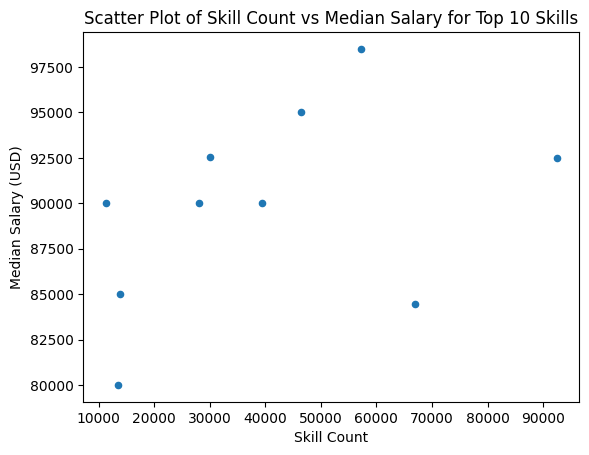

<Figure size 640x480 with 0 Axes>

In [16]:
skill_stats.plot(kind='scatter', x='skill_count', y='median_salary')
plt.xlabel('Skill Count')
plt.ylabel('Median Salary (USD)')
plt.title('Scatter Plot of Skill Count vs Median Salary for Top 10 Skills')
plt.show()
plt.tight_layout()